In [46]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
# Load dataset

df = pd.read_csv(r"C:\Users\tanis\Downloads\Boston Dataset.csv")

# Display first 5 rows

df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [49]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


In [50]:
# Checking missing values

df.isnull().sum()

Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64

In [51]:
# Filling missing values using mean

df = df.fillna(df.mean(numeric_only=True))

# Verify missing values again

df.isnull().sum()

Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64

In [52]:
# Dataset dimensions

df.shape

(506, 15)

In [53]:
# Column names

df.columns

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [54]:
# Statistical summary

df.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


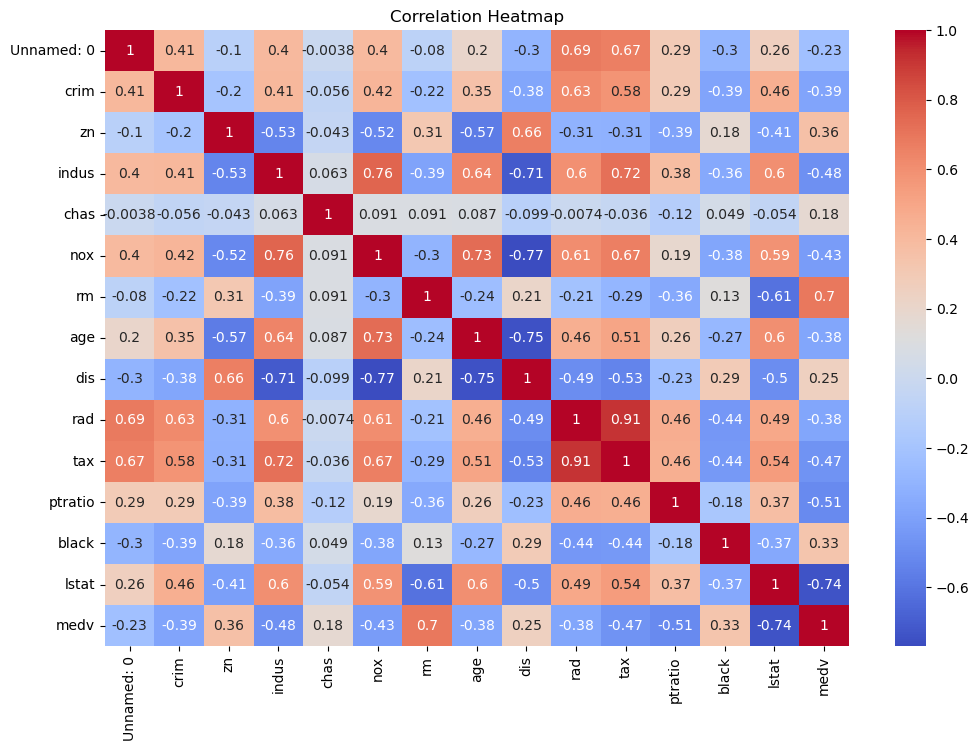

In [55]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [64]:
# Independent variables
X = df.drop('medv', axis=1)

In [65]:
# Dependent variable
y = df['medv']

In [61]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
# Display shapes

X_train.shape

X_test.shape

(102, 14)

In [63]:
# Create Linear Regression model

model = LinearRegression()

In [66]:
# Train model

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
# Predict house prices

y_pred = model.predict(X_test)

y_pred


array([28.97335364, 35.87795794, 13.97366183, 25.61583978, 18.66608153,
       23.64466022, 17.05971239, 14.5264485 , 22.79402759, 19.60618783,
       24.62043501, 19.06428675, -6.27197735, 22.20788474, 18.64849181,
       26.15022718, 20.62835191,  5.77374284, 40.72117979, 17.48530737,
       27.08436097, 29.90818637, 11.65330429, 22.99879937, 17.85048447,
       15.5556251 , 23.31650588, 14.44013189, 22.11106256, 18.20109763,
       22.33391113, 24.79774986, 26.15304018, 17.89425941, 16.52927207,
       17.10592481, 31.77372627, 19.58243073, 23.603617  , 25.2202457 ,
       12.89702838, 31.91216634, 42.90231353, 17.74616574, 27.5000776 ,
       17.06259552, 14.39460992, 26.51167547, 20.10908837, 30.51587021,
       21.74636797, 34.09117218, 16.44234996, 26.62572161, 39.42027423,
       22.49131562, 18.75511558, 32.62323592, 25.35325167, 12.58127149,
       23.23090959, 31.15654212, 31.70938821, 16.555899  , 19.75136599,
       16.30198537, 20.60703158, 26.4253367 , 31.3483927 , 11.44

In [68]:
# Compare actual and predicted values

comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head()

,Actual Price,Predicted Price
173,23.6,28.973354
274,32.4,35.877958
491,13.6,13.973662
72,22.8,25.615840
452,16.1,18.666082


In [69]:
# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

mse

24.497819777630205

In [70]:
# R2 Score

r2 = r2_score(y_test, y_pred)

r2

0.6659408703343062

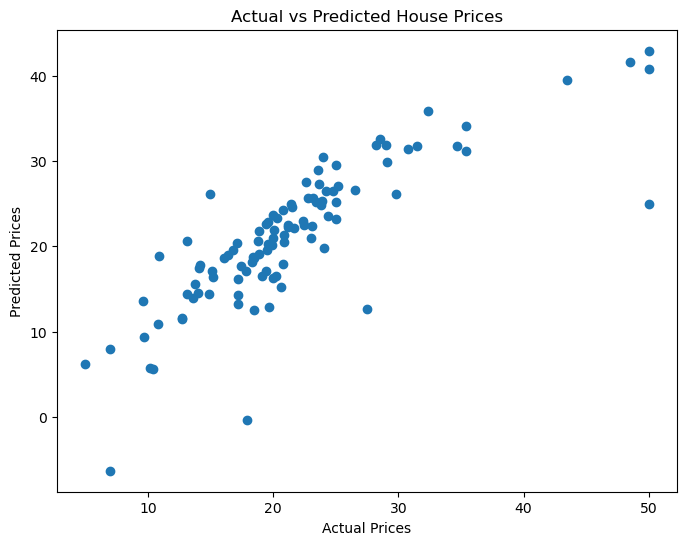

In [71]:
# Scatter plot of Actual vs Predicted Prices

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

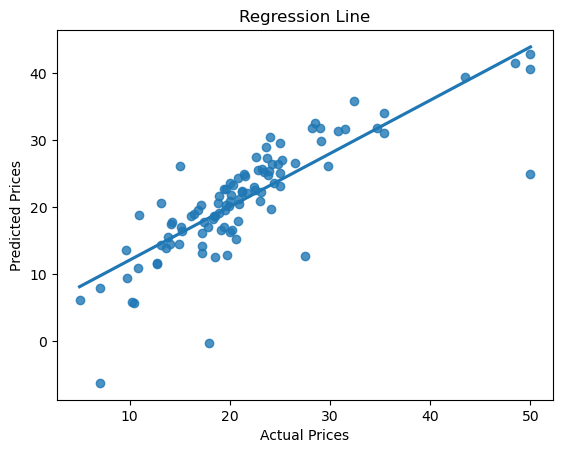

In [72]:
# Regression line visualization

sns.regplot(x=y_test,
            y=y_pred,
            ci=None)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Regression Line")

plt.show()